In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

monthly = pd.read_csv("output_files/monthly_summary.csv")
routes  = pd.read_csv("output_files/profitable_routes.csv")
pickups = pd.read_csv("output_files/top_pickups.csv")
wait    = pd.read_csv("output_files/avg_waiting_time.csv")

print("Data loaded ✓")
monthly.head()

Data loaded ✓


,business,month,trip_count,driver_earnings,platform_profit
0,Lyft,1,3548,39432.20,21367.11
1,Lyft,2,3299,36643.37,19832.78
2,Lyft,3,3567,39691.39,21471.84
3,Lyft,4,3541,39557.00,21320.13
4,Lyft,5,3647,40258.78,21921.94


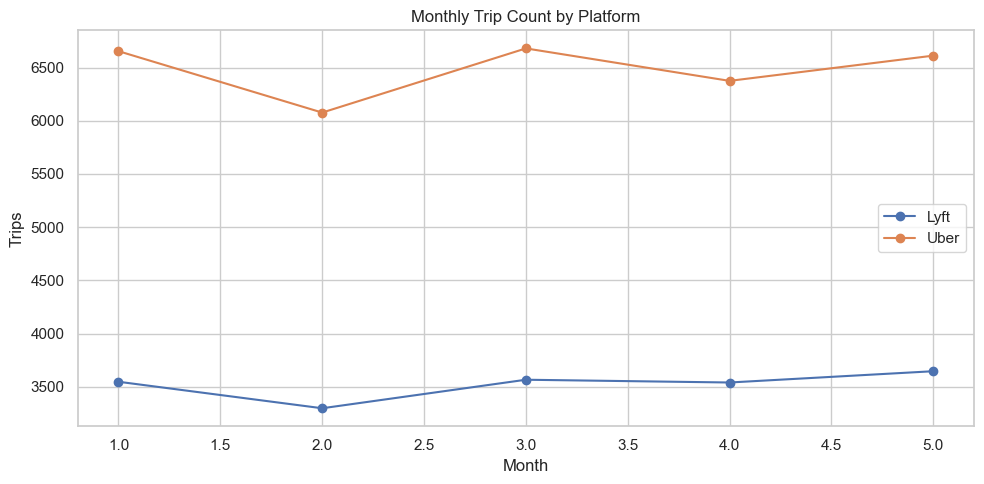

In [6]:
fig, ax = plt.subplots()
for platform, grp in monthly.groupby("business"):
    ax.plot(grp["month"], grp["trip_count"], marker="o", label=platform)

ax.set_title("Monthly Trip Count by Platform")
ax.set_xlabel("Month")
ax.set_ylabel("Trips")
ax.legend()
plt.tight_layout()
plt.savefig("output_files/trip_counts.png", dpi=150)
plt.show()

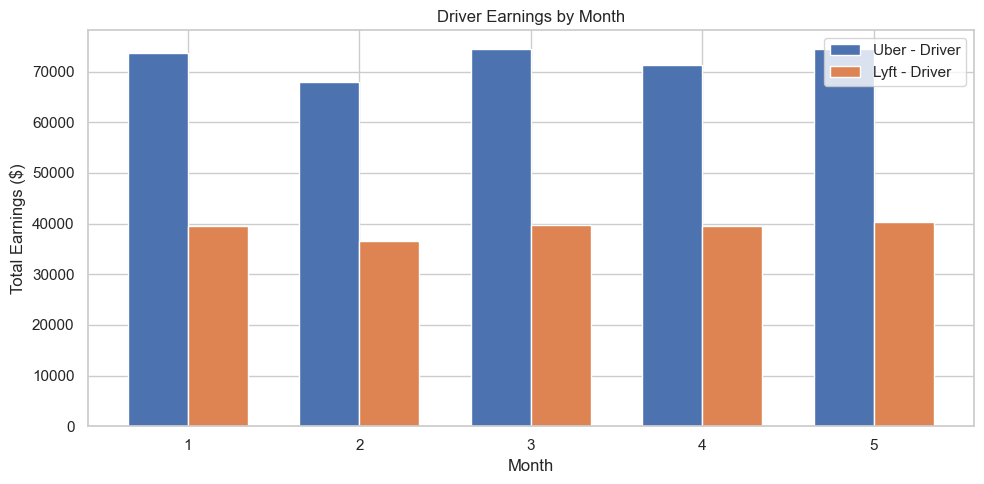

In [7]:
fig, ax = plt.subplots()
width = 0.35
months = monthly["month"].unique()

uber = monthly[monthly["business"] == "Uber"]
lyft = monthly[monthly["business"] == "Lyft"]

ax.bar(uber["month"] - width/2, uber["driver_earnings"], width, label="Uber - Driver")
ax.bar(lyft["month"] + width/2, lyft["driver_earnings"], width, label="Lyft - Driver")
ax.set_title("Driver Earnings by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Earnings ($)")
ax.legend()
plt.tight_layout()
plt.savefig("output_files/driver_earnings.png", dpi=150)
plt.show()

/var/folders/2y/y4qj4g1x5g52ghvwp50kqhqw0000gn/T/ipykernel_33208/2341534568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pickups, x="count", y="pickup_zone", palette="Blues_r", ax=ax)


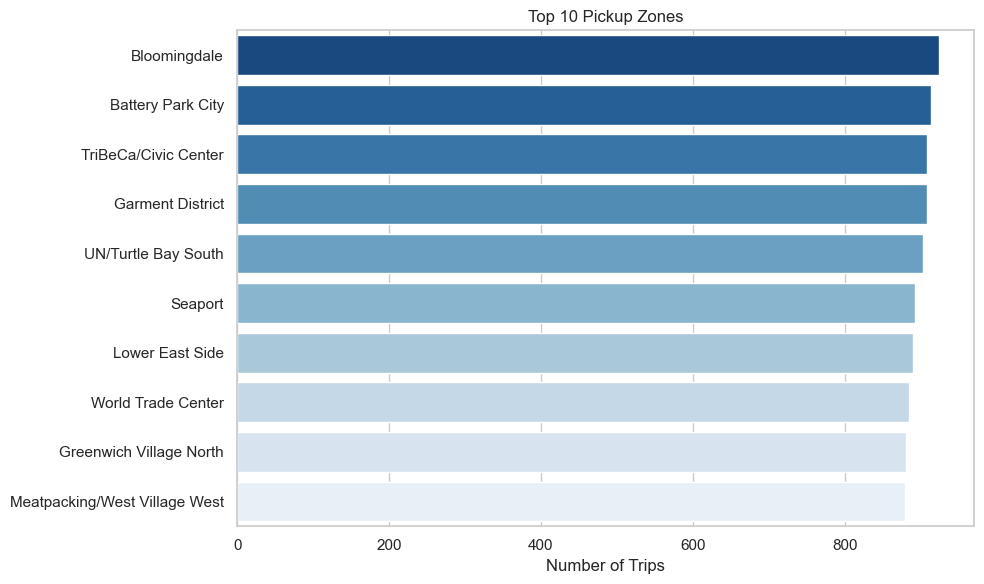

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=pickups, x="count", y="pickup_zone", palette="Blues_r", ax=ax)
ax.set_title("Top 10 Pickup Zones")
ax.set_xlabel("Number of Trips")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("output_files/top_pickups.png", dpi=150)
plt.show()

/var/folders/2y/y4qj4g1x5g52ghvwp50kqhqw0000gn/T/ipykernel_33208/3784548324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wait, x="business", y="avg_wait_minutes", palette="Set2", ax=ax)


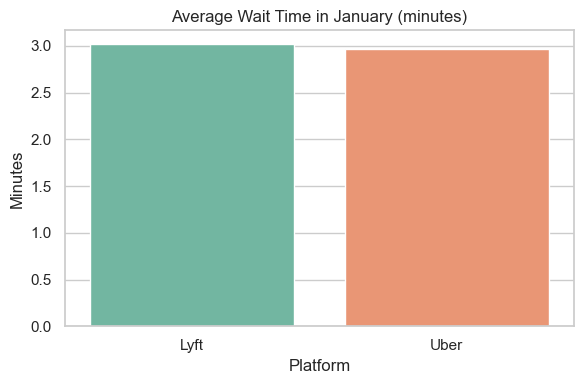

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=wait, x="business", y="avg_wait_minutes", palette="Set2", ax=ax)
ax.set_title("Average Wait Time in January (minutes)")
ax.set_xlabel("Platform")
ax.set_ylabel("Minutes")
plt.tight_layout()
plt.savefig("output_files/avg_wait.png", dpi=150)
plt.show()